Mounted at /content/drive
Loading: /content/drive/MyDrive/Flood_Analysis/final_merged_dataset_rainValidCells.csv

--- Label distribution ---
Y
0    4179
1    2037
Name: count, dtype: int64
Positive rate: 0.3277027027027027
Share Baseline_WF==0: 0.37001287001287003

After dropna: (6216, 10)

Sequence dataset: (5605, 14, 7) (5605,)
Seq positive rate: 0.32809991079393397

--- Split sizes ---
Train: (3363, 14, 7) Val: (1121, 14, 7) Test: (1121, 14, 7)
Train pos rate: 0.327980969372584 Val pos rate: 0.328278322925959 Test pos rate: 0.328278322925959

Training RF...

RF best VAL threshold: 0.306 (Val F1: 0.6188)

--- RF Test metrics ---
PR-AUC: 0.6424135855758352
ROC-AUC: 0.7837598879842946
Brier: 0.17224906788321181
F1 (VAL-threshold): 0.6160427807486631

Confusion matrix:
 [[474 279]
 [ 80 288]]

Classification report:
               precision    recall  f1-score   support

           0     0.8556    0.6295    0.7253       753
           1     0.5079    0.7826    0.6160       368

    accu

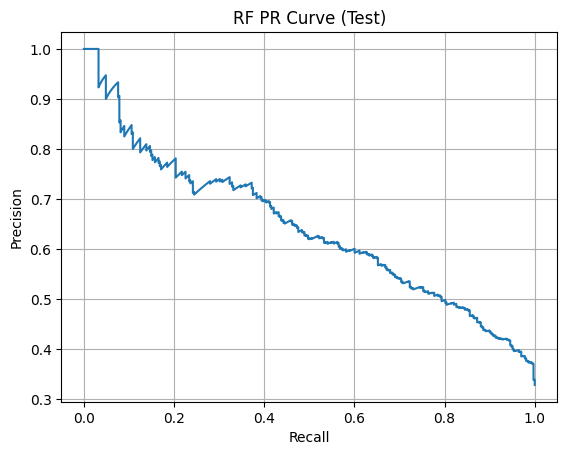

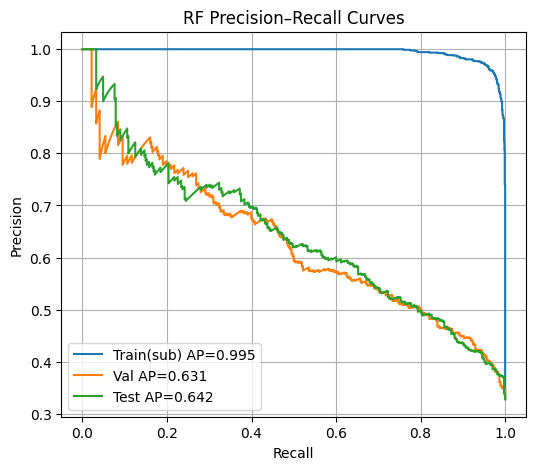

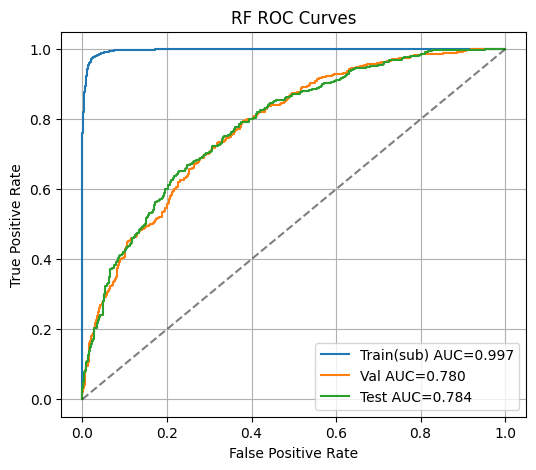

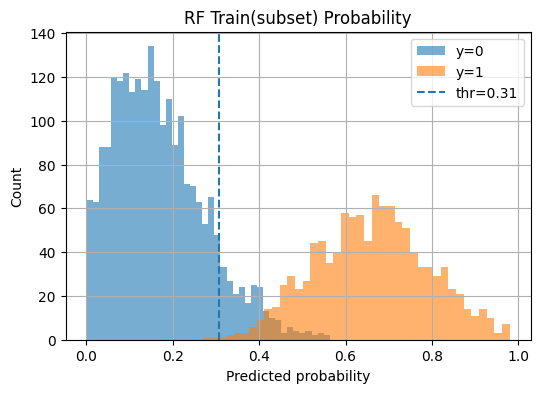

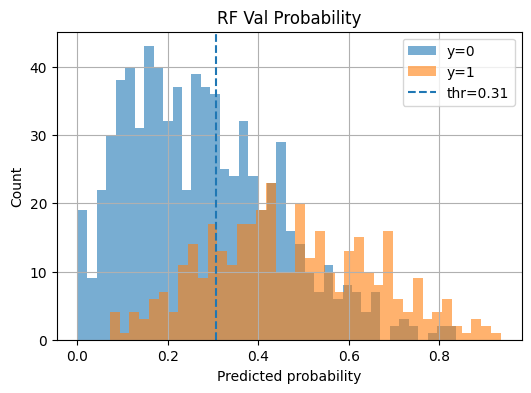

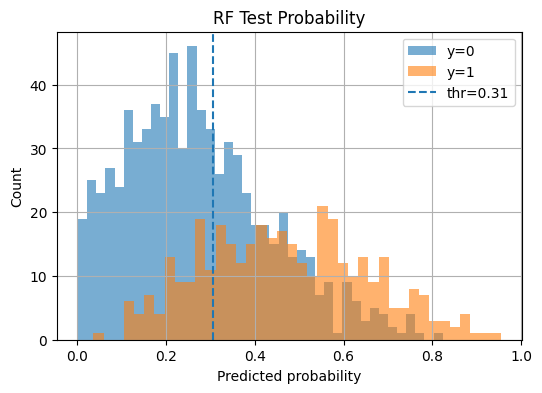


GP training subset: (650, 98) pos_rate: 0.5276923076923077

Training GP...


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



Optimized kernel:
 1.14**2 * Matern(length_scale=5.79, nu=1.5) + WhiteKernel(noise_level=1e-05)

GP best VAL threshold: 0.484 (Val F1: 0.5484)

--- GP Test metrics ---
PR-AUC: 0.4950308673749545
ROC-AUC: 0.6828374906172412
Brier: 0.23427244989596363
F1 (VAL-threshold): 0.541241890639481

Confusion matrix:
 [[334 419]
 [ 76 292]]

Classification report:
               precision    recall  f1-score   support

           0     0.8146    0.4436    0.5744       753
           1     0.4107    0.7935    0.5412       368

    accuracy                         0.5584      1121
   macro avg     0.6127    0.6185    0.5578      1121
weighted avg     0.6820    0.5584    0.5635      1121



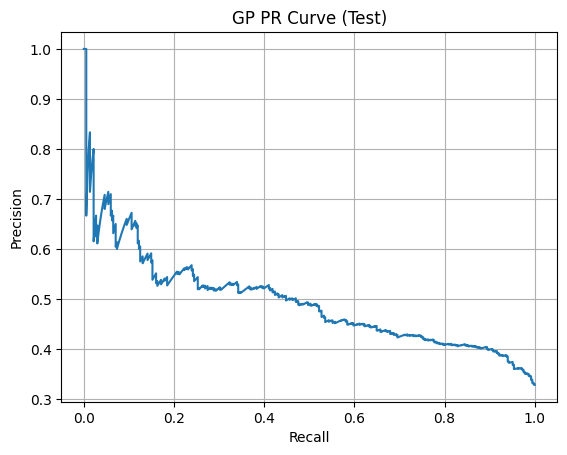

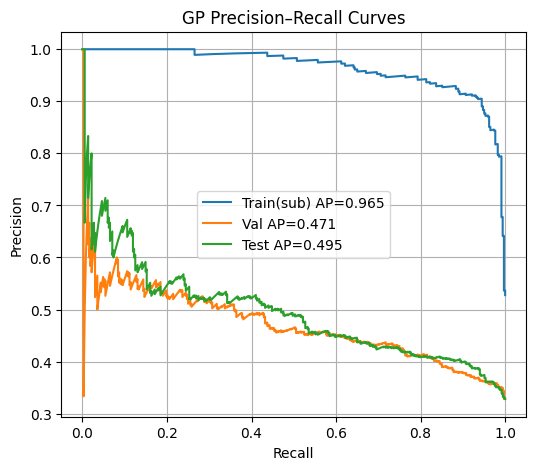

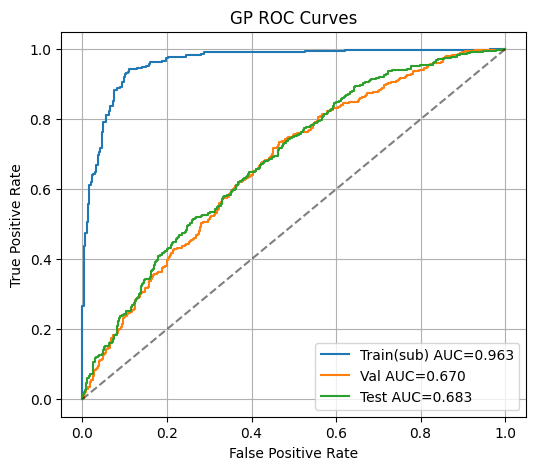

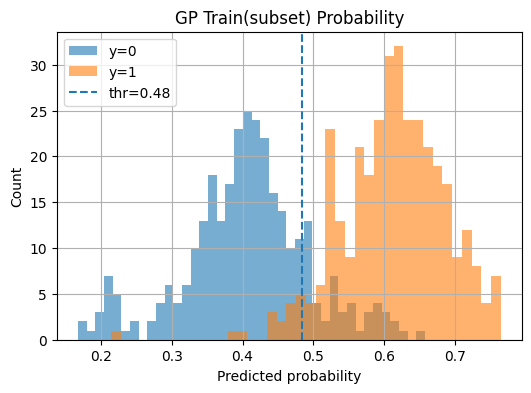

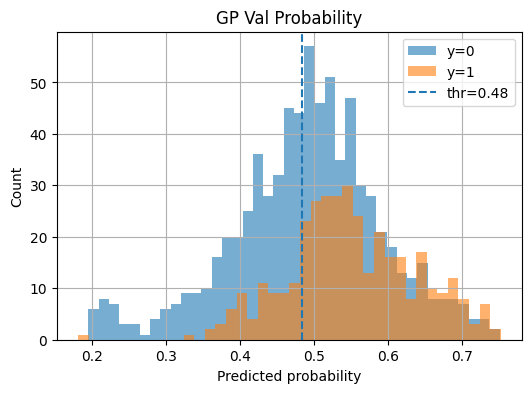

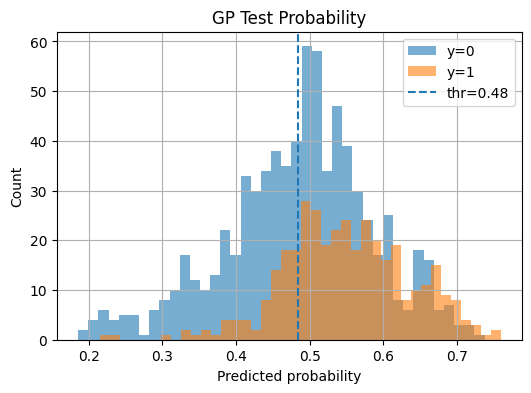


Training LSTM...
Epoch 1/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.6739 - pr_auc: 0.3173 - roc_auc: 0.5072 - val_loss: 0.6283 - val_pr_auc: 0.3507 - val_roc_auc: 0.5625 - learning_rate: 0.0010
Epoch 2/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.6248 - pr_auc: 0.3717 - roc_auc: 0.5651 - val_loss: 0.6235 - val_pr_auc: 0.3715 - val_roc_auc: 0.5917 - learning_rate: 0.0010
Epoch 3/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.6189 - pr_auc: 0.3800 - roc_auc: 0.5830 - val_loss: 0.6169 - val_pr_auc: 0.3854 - val_roc_auc: 0.6114 - learning_rate: 0.0010
Epoch 4/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.6198 - pr_auc: 0.3820 - roc_auc: 0.5817 - val_loss: 0.6139 - val_pr_auc: 0.4026 - val_roc_auc: 0.6291 - learning_rate: 0.0010
Epoch 5/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.6093 - pr_auc: 0.4071 - roc_auc: 0.6100 - val_loss: 0.6080 - val_pr_auc: 0.4154 - val_roc_auc: 0.6440 - learning_rate: 0.0010
Epoch 6/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/s

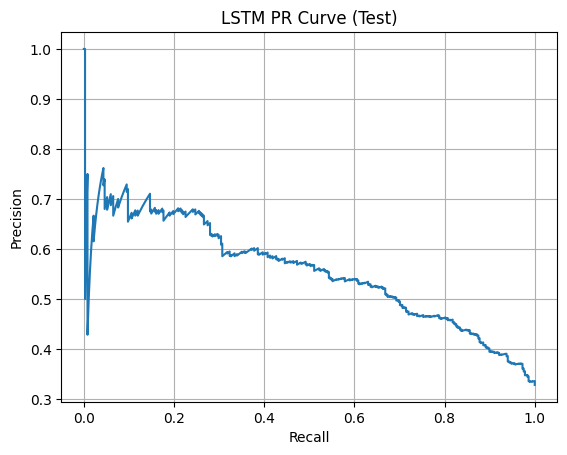

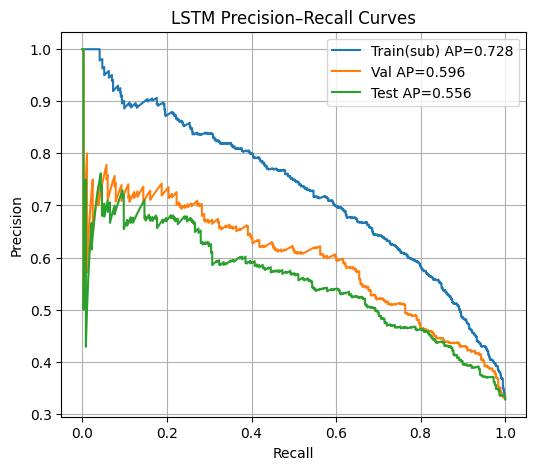

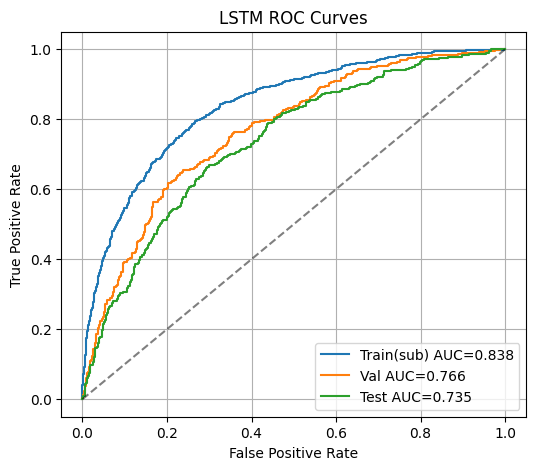

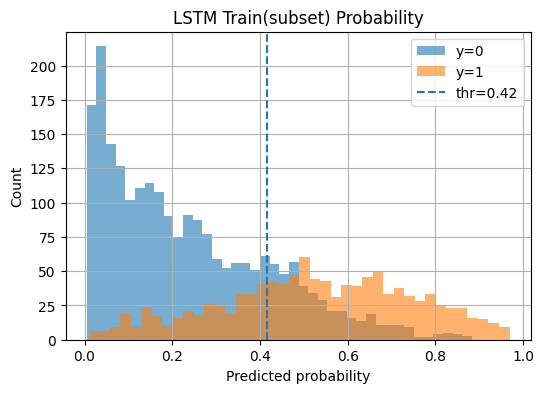

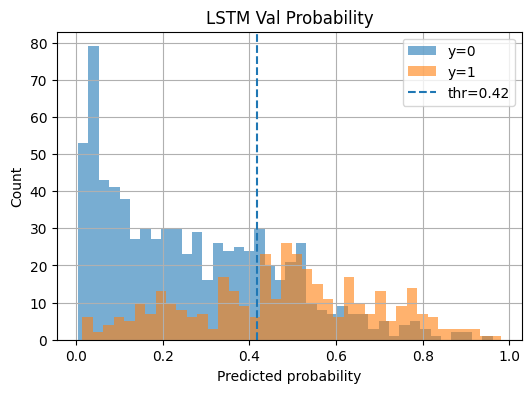

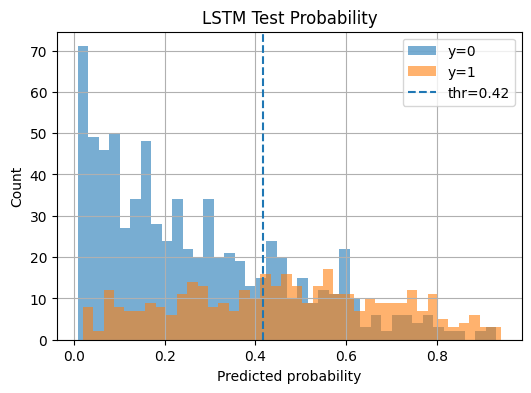


✅ Saved ALL outputs to: /content/drive/MyDrive/Flood_Analysis/seq_mapping_wfnp_outputs_v1


In [1]:
# SEQ mapping (RF + GP + LSTM)
# Dataset: final_merged_dataset_rainValidCells.csv
# Label: WaterFrac_Valid_NoPerm > (median per Region_ID × 1.09)  [strict >]
# Sequence window: 14 days, label at the end of the window
# (No month_sin / month_cos)

import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel

from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    f1_score, brier_score_loss
)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

import joblib


# -----------------------------
# 1) Setup
# -----------------------------
drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/Flood_Analysis"
INPUT_FILE = os.path.join(BASE_DIR, "final_merged_dataset_rainValidCells.csv")

OUT_BASE = os.path.join(BASE_DIR, "seq_mapping_wfnp_outputs_v1")
os.makedirs(OUT_BASE, exist_ok=True)

RANDOM_STATE = 42
SEQ_LEN = 14

FEATURES = [
    "Precip_mm",
    "rain_sum_7", "rain_sum_15", "rain_sum_30", "rain_sum_60", "rain_sum_90",
    "rain_days_7",
]

REGION_COL = "Region_ID"
DATE_COL = "Date"

WF_COL = "WaterFrac_Valid_NoPerm"
RATIO = 1.09

MAX_TRAIN_SAMPLES_GP = 650          # GP: balanced subset, then cap size
MAX_TRAIN_SAMPLES_RF = None         # RF: optional cap (None = off)

EPOCHS = 60
BATCH = 128


# -----------------------------
# 2) Load
# -----------------------------
print(f"Loading: {INPUT_FILE}")
df = pd.read_csv(INPUT_FILE)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL]).copy()


# -----------------------------
# 3) Label
# -----------------------------
if WF_COL not in df.columns:
    raise ValueError(f"{WF_COL} not found in dataset")

df[WF_COL] = pd.to_numeric(df[WF_COL], errors="coerce")

# if values look like percent, convert to 0–1
if df[WF_COL].quantile(0.99) > 1.5:
    df[WF_COL] = df[WF_COL] / 100.0

df[WF_COL] = df[WF_COL].clip(0, 1)
df = df.dropna(subset=[WF_COL]).copy()

df["Baseline_WF"] = df.groupby(REGION_COL)[WF_COL].transform("median")
df["Y"] = (df[WF_COL] > (df["Baseline_WF"] * RATIO)).astype(int)  # strict >

print("\n--- Label distribution ---")
print(df["Y"].value_counts())
print("Positive rate:", df["Y"].mean())
print("Share Baseline_WF==0:", (df["Baseline_WF"] == 0).mean())


# -----------------------------
# 4) Clean + sort
# -----------------------------
needed = [REGION_COL, DATE_COL, "Y"] + FEATURES
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df_model = df[needed].dropna().copy()
df_model = df_model.sort_values([REGION_COL, DATE_COL]).reset_index(drop=True)
print("\nAfter dropna:", df_model.shape)


# -----------------------------
# 5) Make sequences
# -----------------------------
def make_sequences(frame, features, label_col, date_col, region_col, seq_len):
    X_list, y_list = [], []
    for _, g in frame.groupby(region_col, sort=False):
        g = g.sort_values(date_col)
        Xv = g[features].to_numpy(dtype=np.float32)
        yv = g[label_col].to_numpy(dtype=np.int64)

        if len(g) < seq_len:
            continue

        for i in range(seq_len - 1, len(g)):
            X_list.append(Xv[i - seq_len + 1: i + 1])
            y_list.append(yv[i])

    X = np.stack(X_list) if X_list else np.empty((0, seq_len, len(features)), dtype=np.float32)
    y = np.array(y_list, dtype=np.int64)
    return X, y


X_seq, y_seq = make_sequences(df_model, FEATURES, "Y", DATE_COL, REGION_COL, SEQ_LEN)
print("\nSequence dataset:", X_seq.shape, y_seq.shape)
print("Seq positive rate:", y_seq.mean() if len(y_seq) else None)
if len(y_seq) == 0:
    raise ValueError("No sequences created. Check SEQ_LEN and time sorting.")


# -----------------------------
# 6) Split (train/val/test)
# -----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X_seq, y_seq, test_size=0.40, random_state=RANDOM_STATE, stratify=y_seq
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print("\n--- Split sizes ---")
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Train pos rate:", y_train.mean(), "Val pos rate:", y_val.mean(), "Test pos rate:", y_test.mean())


# -----------------------------
# 7) Flatten + standardize (RF/GP)
# -----------------------------
def flatten(X):
    return X.reshape((X.shape[0], -1))


scaler = StandardScaler()
X_train_fs = scaler.fit_transform(flatten(X_train))
X_val_fs = scaler.transform(flatten(X_val))
X_test_fs = scaler.transform(flatten(X_test))


# -----------------------------
# 8) Helpers (threshold + eval + plots)
# -----------------------------
def tune_threshold_on_val(y_true, proba):
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f1s = (2 * prec * rec) / np.maximum(prec + rec, 1e-12)
    best_idx = int(np.nanargmax(f1s))
    best_thr = thr[best_idx - 1] if best_idx > 0 and (best_idx - 1) < len(thr) else 0.5
    best_f1 = float(f1s[best_idx])
    return float(best_thr), float(best_f1)


def eval_classifier(name, y_true, proba, thr):
    pred = (proba >= thr).astype(int)

    pr_auc = float(average_precision_score(y_true, proba))
    roc_auc = float(roc_auc_score(y_true, proba))
    brier = float(brier_score_loss(y_true, proba))
    f1 = float(f1_score(y_true, pred))
    cm = confusion_matrix(y_true, pred)

    print(f"\n--- {name} Test metrics ---")
    print("PR-AUC:", pr_auc)
    print("ROC-AUC:", roc_auc)
    print("Brier:", brier)
    print("F1 (VAL-threshold):", f1)
    print("\nConfusion matrix:\n", cm)
    print("\nClassification report:\n", classification_report(y_true, pred, digits=4, zero_division=0))

    return {
        "test_pr_auc": pr_auc,
        "test_roc_auc": roc_auc,
        "test_brier": brier,
        "test_f1": f1,
        "val_threshold": float(thr),
        "cm": cm.tolist(),
    }, pred


def plot_pr_roc_and_hists(name, y_train_like, train_proba, y_val, val_proba, y_test, test_proba, best_thr, out_dir):
    # PR curve (test)
    p_t, r_t, _ = precision_recall_curve(y_test, test_proba)
    plt.figure()
    plt.plot(r_t, p_t)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{name} PR Curve (Test)")
    plt.grid(True)
    plt.savefig(os.path.join(out_dir, f"{name}_pr_test.png"), dpi=160, bbox_inches="tight")
    plt.show()

    # PR curves across splits
    plt.figure(figsize=(6, 5))
    for split_name, yt, pb in [
        ("Train(sub)", y_train_like, train_proba),
        ("Val", y_val, val_proba),
        ("Test", y_test, test_proba),
    ]:
        p, r, _ = precision_recall_curve(yt, pb)
        ap = average_precision_score(yt, pb)
        plt.plot(r, p, label=f"{split_name} AP={ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{name} Precision–Recall Curves")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(out_dir, f"{name}_pr_splits.png"), dpi=160, bbox_inches="tight")
    plt.show()

    # ROC curves
    plt.figure(figsize=(6, 5))
    for split_name, yt, pb in [
        ("Train(sub)", y_train_like, train_proba),
        ("Val", y_val, val_proba),
        ("Test", y_test, test_proba),
    ]:
        fpr, tpr, _ = roc_curve(yt, pb)
        auc = roc_auc_score(yt, pb)
        plt.plot(fpr, tpr, label=f"{split_name} AUC={auc:.3f}")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} ROC Curves")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(out_dir, f"{name}_roc_splits.png"), dpi=160, bbox_inches="tight")
    plt.show()

    def plot_prob_hist(y, proba, title, fn):
        plt.figure(figsize=(6, 4))
        plt.hist(proba[y == 0], bins=40, alpha=0.6, label="y=0")
        plt.hist(proba[y == 1], bins=40, alpha=0.6, label="y=1")
        plt.axvline(best_thr, linestyle="--", label=f"thr={best_thr:.2f}")
        plt.xlabel("Predicted probability")
        plt.ylabel("Count")
        plt.title(title)
        plt.legend()
        plt.grid(True)
        plt.savefig(os.path.join(out_dir, fn), dpi=160, bbox_inches="tight")
        plt.show()

    plot_prob_hist(y_train_like, train_proba, f"{name} Train(subset) Probability", f"{name}_hist_train.png")
    plot_prob_hist(y_val, val_proba, f"{name} Val Probability", f"{name}_hist_val.png")
    plot_prob_hist(y_test, test_proba, f"{name} Test Probability", f"{name}_hist_test.png")


# -----------------------------
# 9) Model 1 — RF
# -----------------------------
OUT_RF = os.path.join(OUT_BASE, "rf")
os.makedirs(OUT_RF, exist_ok=True)

rf = RandomForestClassifier(
    n_estimators=800,
    random_state=RANDOM_STATE,
    min_samples_leaf=4,
    n_jobs=-1
)

if MAX_TRAIN_SAMPLES_RF is not None and X_train_fs.shape[0] > MAX_TRAIN_SAMPLES_RF:
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(np.arange(X_train_fs.shape[0]), size=MAX_TRAIN_SAMPLES_RF, replace=False)
    X_rf, y_rf = X_train_fs[idx], y_train[idx]
else:
    X_rf, y_rf = X_train_fs, y_train

print("\nTraining RF...")
rf.fit(X_rf, y_rf)

val_proba_rf = rf.predict_proba(X_val_fs)[:, 1]
best_thr_rf, best_f1_val_rf = tune_threshold_on_val(y_val, val_proba_rf)
print(f"\nRF best VAL threshold: {best_thr_rf:.3f} (Val F1: {best_f1_val_rf:.4f})")

test_proba_rf = rf.predict_proba(X_test_fs)[:, 1]
metrics_rf, pred_rf = eval_classifier("RF", y_test, test_proba_rf, best_thr_rf)

joblib.dump(rf, os.path.join(OUT_RF, "rf_seq_model.joblib"))
joblib.dump(scaler, os.path.join(OUT_RF, "scaler.joblib"))

with open(os.path.join(OUT_RF, "metrics.json"), "w") as f:
    json.dump(
        {
            "dataset": os.path.basename(INPUT_FILE),
            "wf_col": WF_COL,
            "ratio": RATIO,
            "seq_len": SEQ_LEN,
            "features": FEATURES,
            "label_method": "per_region_median_times_ratio_strict_gt",
            "best_val_threshold": best_thr_rf,
            "val_best_f1": best_f1_val_rf,
            **metrics_rf,
        },
        f,
        indent=2,
    )

train_proba_rf = rf.predict_proba(X_train_fs)[:, 1]
plot_pr_roc_and_hists("RF", y_train, train_proba_rf, y_val, val_proba_rf, y_test, test_proba_rf, best_thr_rf, OUT_RF)


# -----------------------------
# 10) Model 2 — GP
# -----------------------------
OUT_GP = os.path.join(OUT_BASE, "gp")
os.makedirs(OUT_GP, exist_ok=True)

rng = np.random.default_rng(RANDOM_STATE)
pos_idx = np.where(y_train == 1)[0]
neg_idx = np.where(y_train == 0)[0]

n_pos = len(pos_idx)
n_neg_keep = min(len(neg_idx), n_pos)
neg_keep = rng.choice(neg_idx, size=n_neg_keep, replace=False)

keep_idx = np.concatenate([pos_idx, neg_keep])
rng.shuffle(keep_idx)

X_gp = X_train_fs[keep_idx]
y_gp = y_train[keep_idx]

if MAX_TRAIN_SAMPLES_GP is not None and len(y_gp) > MAX_TRAIN_SAMPLES_GP:
    sub = rng.choice(np.arange(len(y_gp)), size=MAX_TRAIN_SAMPLES_GP, replace=False)
    X_gp, y_gp = X_gp[sub], y_gp[sub]

print("\nGP training subset:", X_gp.shape, "pos_rate:", y_gp.mean())

kernel = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=1e-3)

gp = GaussianProcessClassifier(
    kernel=kernel,
    random_state=RANDOM_STATE,
    max_iter_predict=100
)

print("\nTraining GP...")
gp.fit(X_gp, y_gp)
print("\nOptimized kernel:\n", gp.kernel_)

val_proba_gp = gp.predict_proba(X_val_fs)[:, 1]
best_thr_gp, best_f1_val_gp = tune_threshold_on_val(y_val, val_proba_gp)
print(f"\nGP best VAL threshold: {best_thr_gp:.3f} (Val F1: {best_f1_val_gp:.4f})")

test_proba_gp = gp.predict_proba(X_test_fs)[:, 1]
metrics_gp, pred_gp = eval_classifier("GP", y_test, test_proba_gp, best_thr_gp)

joblib.dump(gp, os.path.join(OUT_GP, "gp_seq_model.joblib"))
joblib.dump(scaler, os.path.join(OUT_GP, "scaler.joblib"))

with open(os.path.join(OUT_GP, "metrics.json"), "w") as f:
    json.dump(
        {
            "dataset": os.path.basename(INPUT_FILE),
            "wf_col": WF_COL,
            "ratio": RATIO,
            "seq_len": SEQ_LEN,
            "features": FEATURES,
            "label_method": "per_region_median_times_ratio_strict_gt",
            "gp_train_subset_n": int(X_gp.shape[0]),
            "gp_train_subset_pos_rate": float(y_gp.mean()),
            "kernel_optimized": str(gp.kernel_),
            "best_val_threshold": best_thr_gp,
            "val_best_f1": best_f1_val_gp,
            **metrics_gp,
        },
        f,
        indent=2,
    )

train_proba_gp = gp.predict_proba(X_gp)[:, 1]
plot_pr_roc_and_hists("GP", y_gp, train_proba_gp, y_val, val_proba_gp, y_test, test_proba_gp, best_thr_gp, OUT_GP)


# -----------------------------
# 11) Model 3 — LSTM
# -----------------------------
OUT_LSTM = os.path.join(OUT_BASE, "lstm")
os.makedirs(OUT_LSTM, exist_ok=True)

tf.keras.utils.set_random_seed(RANDOM_STATE)

mu_seq = X_train.reshape(-1, X_train.shape[-1]).mean(axis=0)
sd_seq = X_train.reshape(-1, X_train.shape[-1]).std(axis=0) + 1e-6
X_train_s = (X_train - mu_seq) / sd_seq
X_val_s = (X_val - mu_seq) / sd_seq
X_test_s = (X_test - mu_seq) / sd_seq

lstm = models.Sequential([
    layers.Input(shape=(SEQ_LEN, X_train_s.shape[-1])),
    layers.LSTM(64),
    layers.Dropout(0.25),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(1, activation="sigmoid")
])

lstm.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
        tf.keras.metrics.AUC(curve="ROC", name="roc_auc"),
    ],
)

cb = [
    callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_pr_auc", mode="max", factor=0.5, patience=4, min_lr=1e-5),
]

print("\nTraining LSTM...")
hist = lstm.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    callbacks=cb,
    verbose=1
)

val_proba_lstm = lstm.predict(X_val_s, batch_size=256).ravel()
best_thr_lstm, best_f1_val_lstm = tune_threshold_on_val(y_val, val_proba_lstm)
print(f"\nLSTM best VAL threshold: {best_thr_lstm:.3f} (Val F1: {best_f1_val_lstm:.4f})")

test_proba_lstm = lstm.predict(X_test_s, batch_size=256).ravel()
metrics_lstm, pred_lstm = eval_classifier("LSTM", y_test, test_proba_lstm, best_thr_lstm)

lstm.save(os.path.join(OUT_LSTM, "lstm_seq_model.keras"))
np.save(os.path.join(OUT_LSTM, "lstm_mu.npy"), mu_seq)
np.save(os.path.join(OUT_LSTM, "lstm_sd.npy"), sd_seq)

with open(os.path.join(OUT_LSTM, "metrics.json"), "w") as f:
    json.dump(
        {
            "dataset": os.path.basename(INPUT_FILE),
            "wf_col": WF_COL,
            "ratio": RATIO,
            "seq_len": SEQ_LEN,
            "features": FEATURES,
            "label_method": "per_region_median_times_ratio_strict_gt",
            "best_val_threshold": best_thr_lstm,
            "val_best_f1": best_f1_val_lstm,
            **metrics_lstm,
        },
        f,
        indent=2,
    )

train_proba_lstm = lstm.predict(X_train_s, batch_size=256).ravel()
plot_pr_roc_and_hists("LSTM", y_train, train_proba_lstm, y_val, val_proba_lstm, y_test, test_proba_lstm, best_thr_lstm, OUT_LSTM)

print(f"\n✅ Saved ALL outputs to: {OUT_BASE}")
